In [1]:
%load_ext autoreload
%autoreload 2

import logging
import math
import os

from ema_pytorch import EMA
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm 
import numpy as np
from sklearn.neighbors import KernelDensity
import torch
from torchcfm.optimal_transport import OTPlanSampler

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [2]:
sample_dir = "sample/2d"
model_dir = "models/2d"
fig_dir = "figs/2d"

os.makedirs(sample_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

## Data

In [3]:
def eight_normal_sample(n, dim=2, scale=5, var=0.3):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), var * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data.to(torch.float32)
    
def eight_normal_log_prob(x, dim=2, scale=5, var=0.3):
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    
    # Compute per-component densities
    sigma2 = var
    normalization = -0.5 * dim * torch.log(2 * torch.tensor(np.pi) * sigma2)
    log_probs = []
    for center in centers:
        log_prob = normalization - torch.sum((x - center) ** 2, dim=-1) / (2 * sigma2)
        log_probs.append(log_prob)
    log_probs = torch.stack(log_probs, dim=-1)
    # Log-sum-exp trick for numerical stability
    max_log_prob, _ = torch.max(log_probs, dim=-1, keepdim=True)
    mixture_log_prob = max_log_prob + torch.log(torch.sum(torch.exp(log_probs - max_log_prob), dim=-1, keepdim=True)) - torch.log(torch.tensor(len(centers))).squeeze()
    return mixture_log_prob

## Model

In [4]:
class MLP3(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=64):
        super().__init__()
        
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + 2, w),
            torch.nn.ReLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)

def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u)
    jac = lambda x, *args: J(x)
    return jac
    # return lambda x, *args: torch.trace(J(x))


def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn

## Training setup

In [5]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
dim = 2
model = MLP3(dim=dim, w=64)

ema = EMA(
    model,
    beta = 0.999,              # exponential moving average factor
    update_after_step = 5_000,    # only after this number of .update() calls will it start updating
    update_every = 1,          # how often to actually update, to save on compute (updates every 10th .update() call)
)

optimizer = torch.optim.AdamW(model.parameters(), 0.01, weight_decay=0.1)
M = 128
bootstrap_every = 8
log2_sections = np.log2(M).astype(np.int32)

use_ot = False
num_iterations = 25_000 if use_ot else 50_000

## Flow targets

In [6]:
ot_sampler = OTPlanSampler(method="exact")

def get_targets(model,
                images, 
                force_t=-1, 
                force_dt=-1):

    device = images.device  # Or wherever you’d like your tensors to live (cuda, cpu, etc.)
    info = {}

    noise = torch.randn_like(images)

    # Get OT coupling

    if use_ot:
        noise, images = ot_sampler.sample_plan(noise, images)

    # -----------------------------------------------------------------
    #  1) =========== Sample dt. ============
    # -----------------------------------------------------------------
    bootstrap_batchsize = batch_size // bootstrap_every
    log2_sections = int(np.log2(M))

    dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32)  # [0, 1, 2, ..., log2_sections-1]
    dt_array = (log2_sections - 1 - dt_range)  # e.g. [log2_sections-1, ..., 0]
    repeated = dt_array.repeat(bootstrap_batchsize // log2_sections)
    needed = bootstrap_batchsize - repeated.shape[0]
    dt_base = torch.cat([repeated, torch.zeros(needed, device=device, dtype=torch.int32)], dim=0)

    force_dt_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_dt
    dt_base = dt_base.to(torch.float32)  # cast to float to match usage below
    dt_base = torch.where(force_dt_vec != -1, force_dt_vec, dt_base)  # if force_dt != -1, use that

    # dt = 1 / (2^(dt_base)) 
    dt = 1.0 / (2.0 ** dt_base)

    dt_base_bootstrap = dt_base + 1.0
    dt_bootstrap = dt / 2.0

    # -----------------------------------------------------------------
    #  2) =========== Sample t. ============
    # -----------------------------------------------------------------
    dt_sections = 2.0 ** dt_base

    # We want to sample t ~ Uniform{0, dt_sections[i]} (integer), then divide by dt_sections[i].
    # This is somewhat trickier to do in a single vectorized call in PyTorch 
    # (because each batch element can have a different max). 
    # We'll do it in a loop for clarity:

    t_list = []
    for i in range(bootstrap_batchsize):
        maxval = int(dt_sections[i].item())  # dt_sections[i] is float, convert to int
        # If maxval == 0 for some reason, clamp to 1 to avoid errors
        if maxval < 1:
            maxval = 1
        # Sample an integer in [0, maxval)
        t_i = torch.randint(low=0, high=maxval, size=(1,), device=device, dtype=torch.int64)
        t_list.append(t_i)

    t = torch.cat(t_list, dim=0).to(torch.float32)      # shape [bootstrap_batchsize]
    t = t / dt_sections                                 # elementwise scale to [0, 1]

    # force_t logic
    force_t_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_t
    t = torch.where(force_t_vec != -1, force_t_vec, t)
    t_full = t.view(-1, 1)

    # -----------------------------------------------------------------
    #  3) =========== Generate Bootstrap Targets ============
    # -----------------------------------------------------------------


    x_1 = images[:bootstrap_batchsize]
    x_0 = noise[:bootstrap_batchsize]
    x_t = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1

    with torch.no_grad():
        v_b1 = model(torch.cat([x_t, t[:, None], dt_base_bootstrap[:, None]], dim=-1))
    
    t2 = t + dt_bootstrap
    x_t2 = x_t + dt_bootstrap.view(-1, 1) * v_b1
    x_t2 = torch.clamp(x_t2, -4.0, 4.0)

    with torch.no_grad():
        v_b2 = model(torch.cat([x_t2, t2[:, None], dt_base_bootstrap[:, None]], dim=-1))

    v_target = 0.5 * (v_b1 + v_b2)
    v_target = torch.clamp(v_target, -4.0, 4.0)

    bst_v = v_target
    bst_dt = dt_base
    bst_t = t
    bst_xt = x_t

    # -----------------------------------------------------------------
    #  4) =========== Generate Flow-Matching Targets ============
    # -----------------------------------------------------------------


    # Sample t uniformly in [0, denoise_timesteps), then / denoise_timesteps
    t_rand = torch.randint(0, M, (images.shape[0],), device=device)
    t_float = t_rand.to(torch.float32) / M

    force_t_vec = torch.ones(images.shape[0], device=device, dtype=torch.float32) * force_t
    t_float = torch.where(force_t_vec != -1, force_t_vec, t_float)
    t_full = t_float.view(-1, 1)

    # x_0 ~ N(0, 1)
    x_0 = noise
    x_1 = images

    # x_t = (1 - alpha * t) * x_0 + t * x_1  (with alpha=1-1e-5 in your code)
    x_t_flow = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1
    v_t_flow = x_1 - (1.0 - 1e-5) * x_0

    dt_flow = int(np.log2(M))
    dt_base_flow = torch.ones(images.shape[0], device=device, dtype=torch.int32) * dt_flow

    # -----------------------------------------------------------------
    #  5) =========== Merge Flow + Bootstrap =============
    # -----------------------------------------------------------------
    bst_size = batch_size // bootstrap_every
    bst_size_data = batch_size - bst_size

    # Combine the bootstrap slices with the flow slices
    x_t_final = torch.cat([bst_xt, x_t_flow[-bst_size_data:]], dim=0)
    t_final = torch.cat([bst_t, t_float[-bst_size_data:]], dim=0)
    dt_base_final = torch.cat([bst_dt, dt_base_flow[-bst_size_data:]], dim=0)
    v_t_final = torch.cat([bst_v, v_t_flow[-bst_size_data:]], dim=0)

    # A few diagnostics
    info["bootstrap_ratio"] = torch.mean((dt_base_final != dt_flow).float())
    info["v_magnitude_bootstrap"] = torch.sqrt(torch.mean(bst_v**2))
    info["v_magnitude_b1"] = torch.sqrt(torch.mean(v_b1**2))
    info["v_magnitude_b2"] = torch.sqrt(torch.mean(v_b2**2))

    return x_t_final, v_t_final, t_final, dt_base_final, info


## Training loop

In [7]:
def train():
    for i in range(num_iterations):
        optimizer.zero_grad()
        x_1 = eight_normal_sample(batch_size) / math.sqrt(12.8) # standardise the data
        x_t_final, v_t_final, t_final, dt_base_final, info = get_targets(model, x_1)
        v_t_pred = model(torch.cat([x_t_final, t_final[:, None], dt_base_final[:, None]], dim=-1))
        flow_loss = torch.mean((v_t_pred - v_t_final) ** 2, dim=-1)
        loss = flow_loss.mean()
        loss.backward()
        bootstrap_size = batch_size // bootstrap_every
        info['loss_flow'] = torch.mean(flow_loss[bootstrap_size:]).item()
        info['loss_bootstrap'] = torch.mean(flow_loss[:bootstrap_size]).item()
        if (i + 1) % 500 == 0:
            logging.info(f"Step [{i+1}/{num_iterations}] - Flow Loss: {info['loss_flow']:.4f} Bootstrap Loss: {info['loss_bootstrap']:.4f} ")
        optimizer.step()
        ema.update()
    return model

model_path = model_dir + f'/ema_ot_{use_ot}.pth'
if not os.path.exists(model_path): 
    # if no saved model, train
    model = train()
    torch.save(ema.state_dict(), model_path)
    logging.info(f"Model saved to {model_path}")
else:
    # load saved model
    ema.load_state_dict(torch.load(model_path))
    logging.info(f"Model loaded from {model_path}")


/var/folders/gc/0119ch550jvf4tpgb_30d6hr0000gr/T/ipykernel_2872/12078765.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ema.load_state_dict(torch.load(model_path))
202

## Sampling setup

In [8]:
# To use the EMA model for evaluation, set use_ema to True
use_ema = False
eval_model = ema if use_ema else ema.model

# How many samples to draw from the model, and how many to draw from the resampling distribution
num_samples = 4196 * 256
num_resamples = num_samples

## Sample functions

In [9]:
from torch.distributions import MultivariateNormal

prior = MultivariateNormal(torch.zeros(dim, device=device), torch.eye(dim, device=device))

@torch.no_grad()
def shortcut_inference(model, num_samples, denoise_timesteps=128, no_shortcut=False):
    
    x0 = prior.sample((num_samples,))

    x = x0
    delta_t = 1.0 / denoise_timesteps
    div, div_gauss, div_rad = 0.0, 0.0, 0.0

    traj = []
    for i in range(denoise_timesteps):
        t = i / denoise_timesteps
        
        # Build t_vector and dt_vectors for input to model
        t_vector = torch.full((x.shape[0],), t, device=device, dtype=torch.float32)
        dt_flow = int(np.log2(denoise_timesteps))
        dt_base = torch.ones(x.shape[0], dtype=torch.int32, device=device) * dt_flow

        # Get the vector field at this point
        v = model(torch.cat([x, t_vector[:, None], dt_base[:, None]], dim=-1))

        # Function to compute vector field (used to compute div)
        def vecfield(y):
            t_in_func = t_vector[0].detach().unsqueeze(0)
            if no_shortcut:
                dt_base_in_func = torch.ones_like(dt_base[0]).detach().unsqueeze(0) * int(np.log2(M))
            else:
                dt_base_in_func = dt_base[0].detach().unsqueeze(0)
            out_v = model(torch.cat([y.unsqueeze(0), t_in_func[:, None], dt_base_in_func[:, None]], dim=-1)).squeeze()
            return out_v

        # Exact Div Calculation 
        jac_fn = torch.func.jacrev(vecfield)
        jac = torch.func.vmap(jac_fn)(x)
        div = div + (jac[:, 0, 0] + jac[:, 1, 1]) * delta_t # God Bless ChatGPT

        # Hutch Div Calculation (Gaussian)
        eps_gauss = torch.randn_like(x)
        jac_gauss = torch.vmap(div_fn_hutch_trace(vecfield))(x, eps_gauss)
        div_gauss = div_gauss + jac_gauss * delta_t

        # Hutch Div Calculation (Rademacher)
        eps_rad = torch.randint_like(x, low=0, high=2).float() * 2 - 1.0
        jac_rad = torch.vmap(div_fn_hutch_trace(vecfield))(x, eps_rad)
        div_rad = div_rad + jac_rad * delta_t

        # Euler sampling
        x = x + v * delta_t
        traj.append(x.detach())

    traj = torch.stack(traj).detach() * math.sqrt(12.8) # destandardise the data

    log_prob_dict = {} 
    log_prob_dict["true"] = eight_normal_log_prob(traj[-1]).flatten().detach()
    log_prob_dict["jacrev"] = (prior.log_prob(x0) - div).flatten().detach()
    log_prob_dict["gauss"] = (prior.log_prob(x0) - div_gauss).flatten().detach()
    log_prob_dict["rad"] = (prior.log_prob(x0) - div_rad).flatten().detach()

    return traj, log_prob_dict

@torch.no_grad()
def importance_sample(samples, true_lop_prob, est_log_prob, num_resamples):

    importance_weights = torch.exp(true_lop_prob - est_log_prob)
    importance_weights = importance_weights / torch.sum(importance_weights)
    resampled_samples = samples[torch.multinomial(importance_weights, num_resamples, replacement=True)]

    return resampled_samples

## Generate samples + resample

In [10]:
import joblib
from collections import defaultdict

data_dict = defaultdict(dict) # to store the sampled / resampled points

for num_timesteps in [1, 2, 4, 8, 16, 32, 64, 128]:

    if num_timesteps not in [1, 2, 4, 8, 16, 32, 64, 128]:
        assert num_timesteps > 128
        no_shortcut = True
    else:
        no_shortcut = False

    shortcut_traj, shortcut_logp_dict = shortcut_inference(eval_model, num_samples=num_samples, denoise_timesteps=num_timesteps, no_shortcut=no_shortcut)
    logging.info(f"Points generated @ {num_timesteps} timesteps")
    shortcut_samples = shortcut_traj[-1]

    samples_dict = {}
    for est_name in ["jacrev", "gauss", "rad"]: # iterate over the different divergence estimators
        resampled_samples = importance_sample(shortcut_samples, shortcut_logp_dict["true"], shortcut_logp_dict[est_name], num_resamples=num_resamples)
        logging.info(f"Points resampled ({est_name}) @ {num_timesteps} timesteps")
        samples_dict[est_name] = resampled_samples

    data_dict[num_timesteps] = {**samples_dict, "original": {"samples": shortcut_samples, **shortcut_logp_dict}}

_ = joblib.dump(data_dict, sample_dir + f"/samples_ot_{use_ot}_ema_{use_ema}.pkl")
logging.info(f"Data saved to {sample_dir + f'/samples_ot_{use_ot}_ema_{use_ema}.pkl'}")

2025-01-05 13:14:38,172 - INFO - Points generated @ 1 timesteps
2025-01-05 13:14:38,290 - INFO - Points resampled (jacrev) @ 1 timesteps
2025-01-05 13:14:38,369 - INFO - Points resampled (gauss) @ 1 timesteps
2025-01-05 13:14:38,478 - INFO - Points resampled (rad) @ 1 timesteps
2025-01-05 13:14:43,287 - INFO - Points generated @ 2 timesteps
2025-01-05 13:14:43,396 - INFO - Points resampled (jacrev) @ 2 timesteps
2025-01-05 13:14:43,474 - INFO - Points resampled (gauss) @ 2 timesteps
2025-01-05 13:14:43,582 - INFO - Points resampled (rad) @ 2 timesteps
2025-01-05 13:14:53,178 - INFO - Points generated @ 4 timesteps
2025-01-05 13:14:53,288 - INFO - Points resampled (jacrev) @ 4 timesteps
2025-01-05 13:14:53,372 - INFO - Points resampled (gauss) @ 4 timesteps
2025-01-05 13:14:53,496 - INFO - Points resampled (rad) @ 4 timesteps
2025-01-05 13:15:13,576 - INFO - Points generated @ 8 timesteps
2025-01-05 13:15:13,686 - INFO - Points resampled (jacrev) @ 8 timesteps
2025-01-05 13:15:13,764 - 

## Plotting utils

In [11]:
# Define limits for consistent plots
xmin, ymin = -10, -10
xmax, ymax = 10, 10

# Create a grid for density evaluation
grid_density = 100
X, Y = np.meshgrid(np.linspace(xmin, xmax, grid_density),
                   np.linspace(ymin, ymax, grid_density))
grid = np.vstack([X.ravel(), Y.ravel()]).T

def scatter_plot(ax, samples, title):
    ax.scatter(samples[:,0], samples[:,1])
    ax.set_title(title)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])

def histogram_plot(ax, samples, title):
    sc = ax.hist2d(samples[:,0], samples[:,1], bins=100, range=[[-10, 10], [-10, 10]], cmap='viridis', norm=LogNorm(), density=True)
    ax.set_title(title)
    plt.colorbar(sc[3], ax=ax)

def histogram_diff(ax, true_samples, model_samples, title):

    # Compute 2D histograms
    bins = 100
    hist_range = [[-10, 10], [-10, 10]]  # [ [xmin,xmax], [ymin,ymax] ]

    H1, xedges, yedges = np.histogram2d(true_samples[:, 0], true_samples[:, 1], bins=bins, range=hist_range)
    H2, _, _ = np.histogram2d(model_samples[:, 0], model_samples[:, 1], bins=bins, range=hist_range)

    H1 = H1 / H1.sum()
    H2 = H2 / H2.sum()

    # Compute difference: H1 - H2
    diff = H1 - H2

    #   e.g., min_val = -max_abs_value, max_val = +max_abs_value
    max_abs = max(abs(diff.min()), abs(diff.max()))

    # TwoSlopeNorm allows us to center the colormap at zero
    norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

    # imshow wants the data in the shape (ny, nx); H1 is (bins_y, bins_x),
    # so we typically transpose it, depending on how we want X/Y oriented.
    # We'll also flip it with origin='lower' and set extent so the axes line up.
    sc = ax.imshow(
        diff.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='RdBu',     # Diverging colormap
        norm=norm,       # Center at 0
        aspect='auto'
    )

    # Colorbar
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)

def kde_log_density(samples, grid, bandwidth=0.3):

    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(samples)

    # Evaluate log density on the grid
    log_density = kde.score_samples(grid)

    # Reshape for plotting
    log_density_2d = log_density.reshape(X.shape)

    return log_density_2d

def plot_density_2d(ax, log_density_2d, title, cbar=True, clim=None):
    sc = ax.imshow(log_density_2d, origin='lower',
               extent=[xmin, xmax, ymin, ymax],
               aspect='auto', cmap='viridis')
    if cbar:
        plt.colorbar(sc, ax=ax)
    if clim is not None:
        sc.set_clim(clim)
    ax.set_title(title)

## Plotting - scatter + histogram

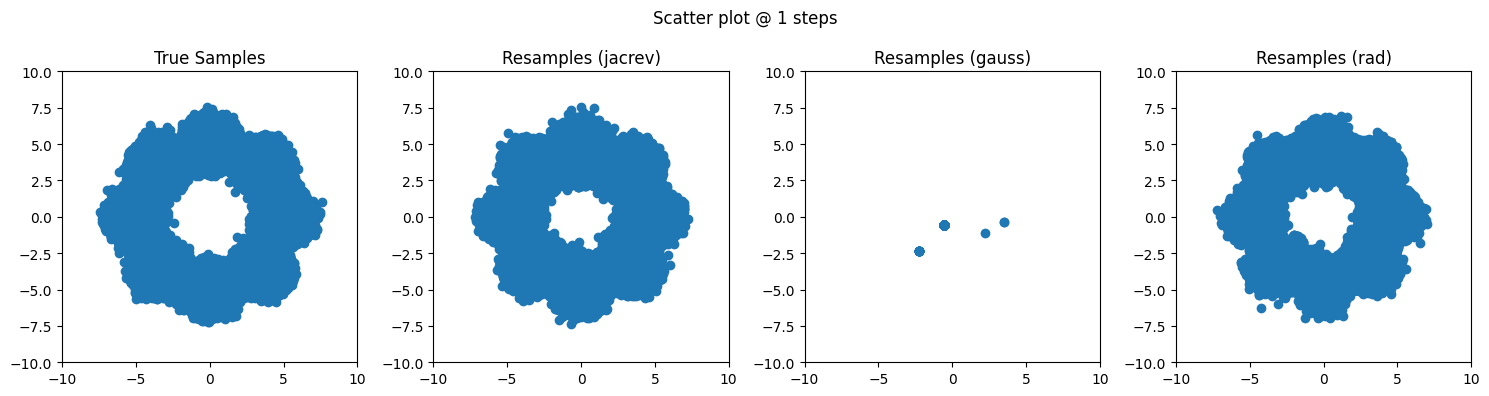

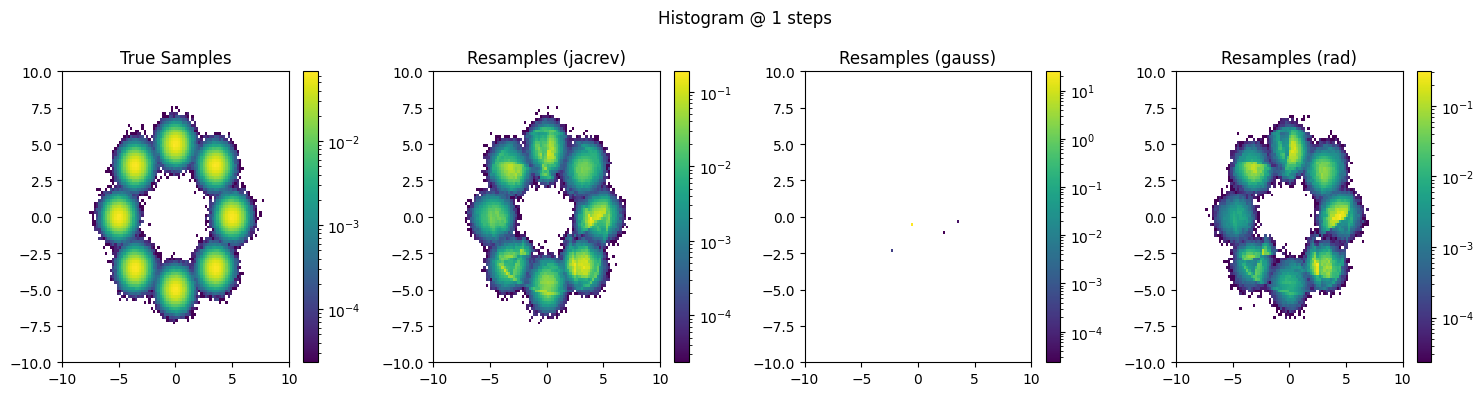

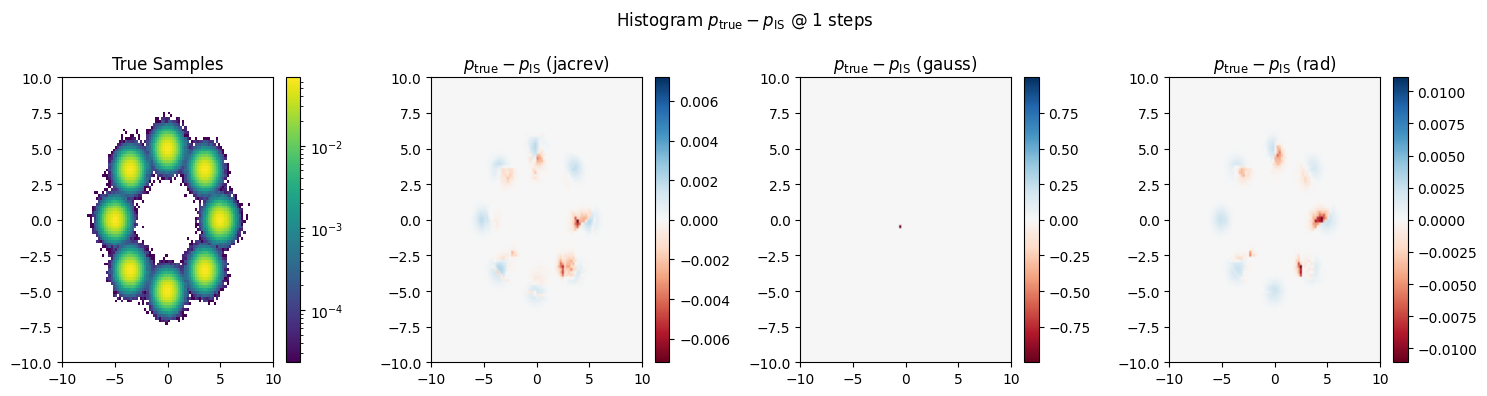

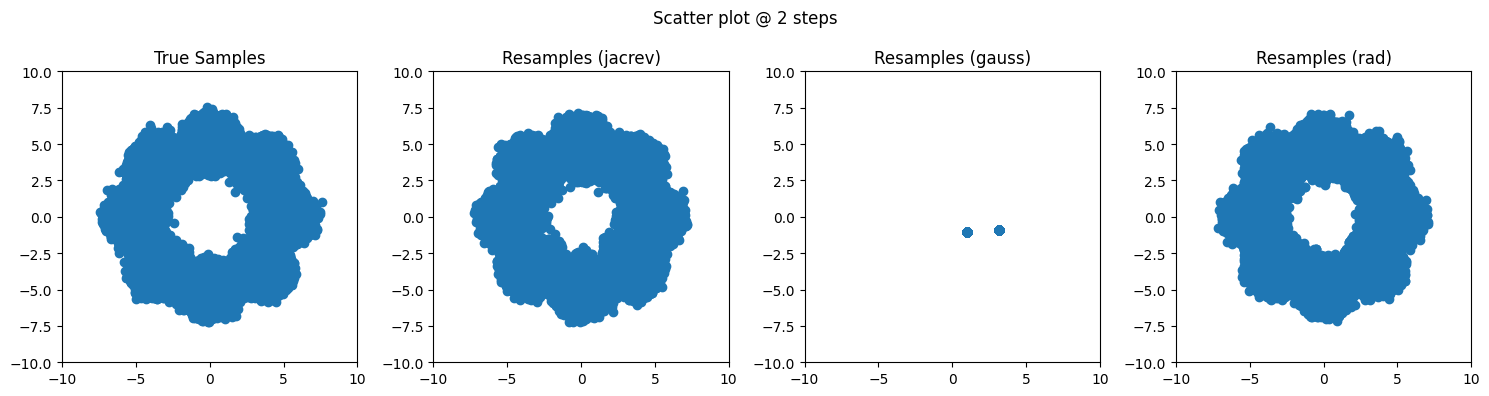

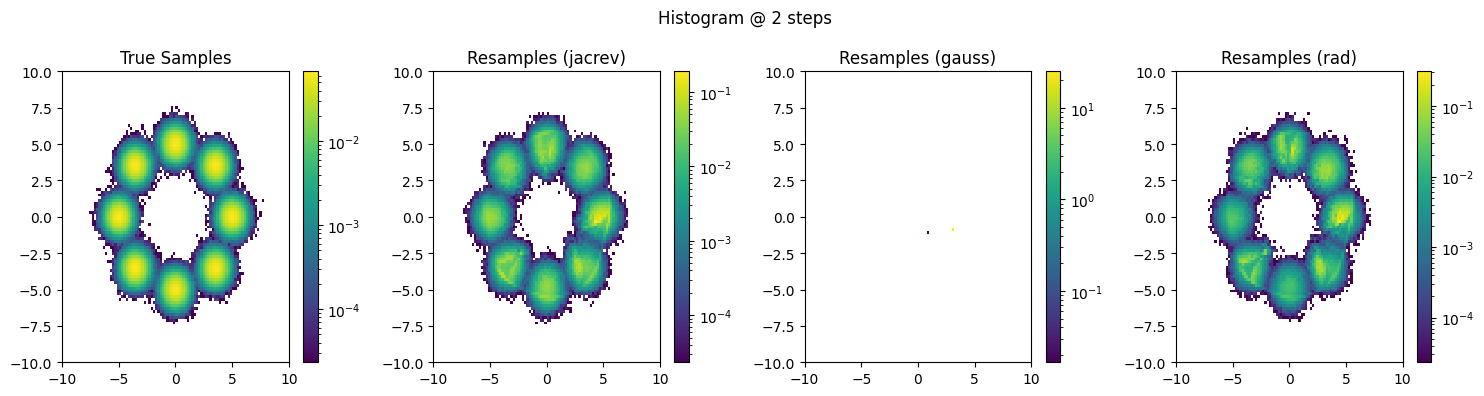

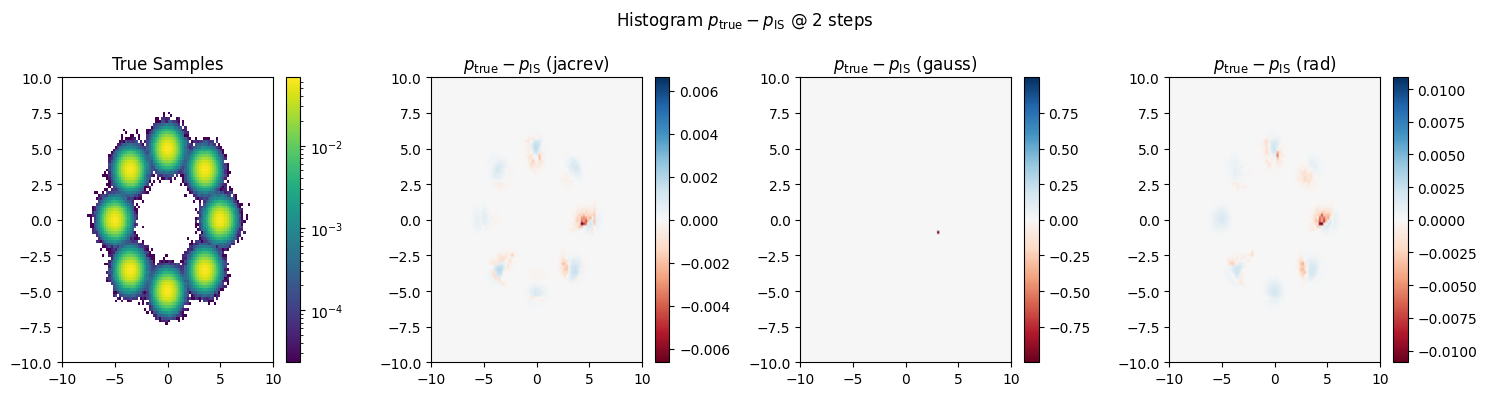

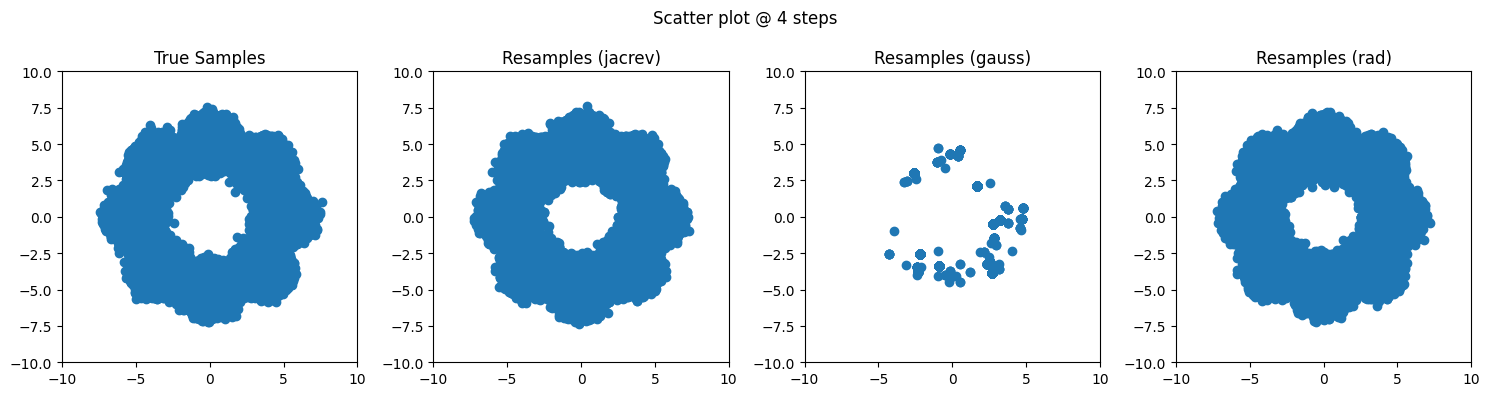

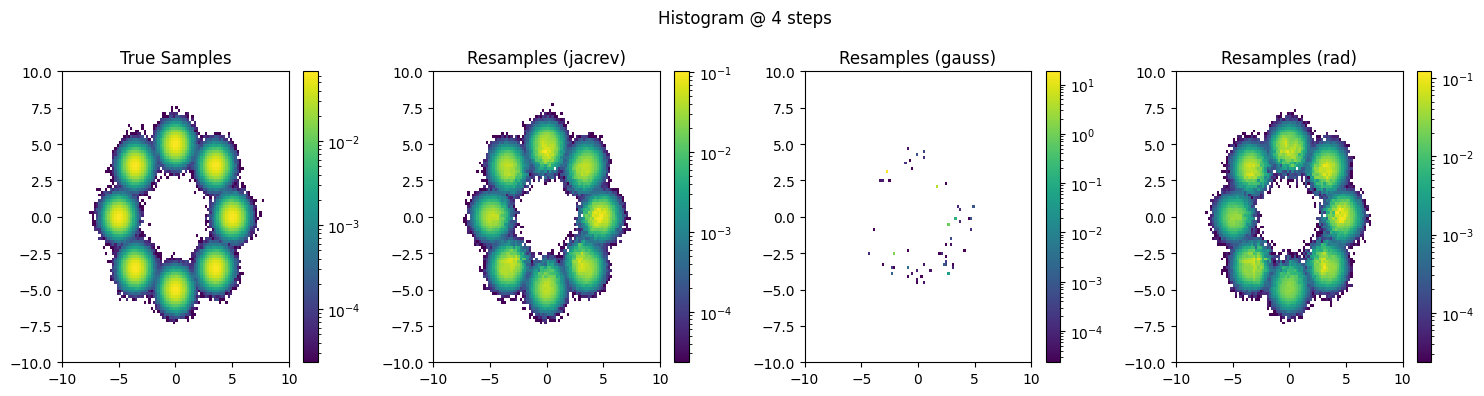

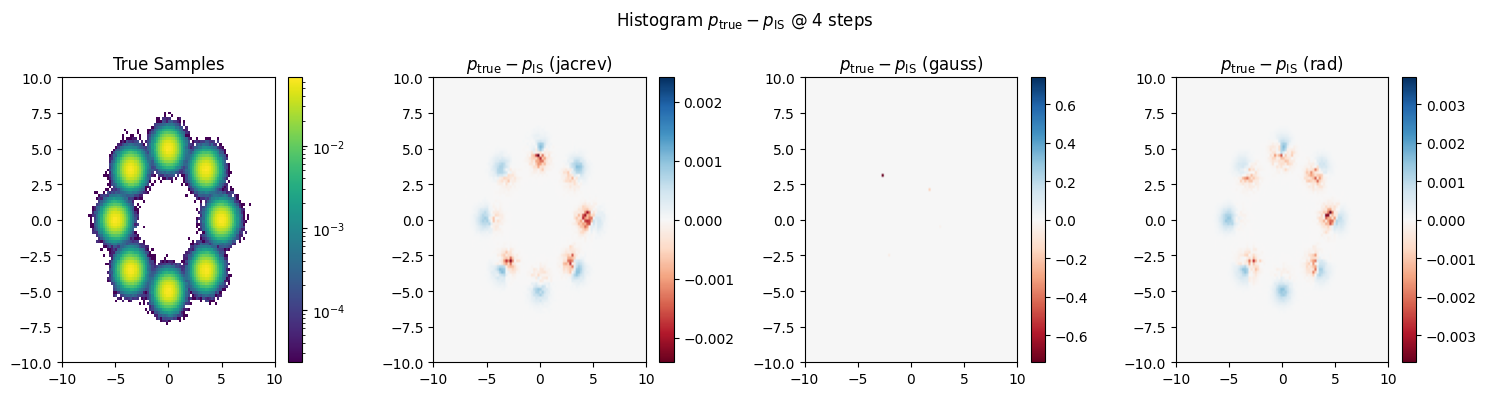

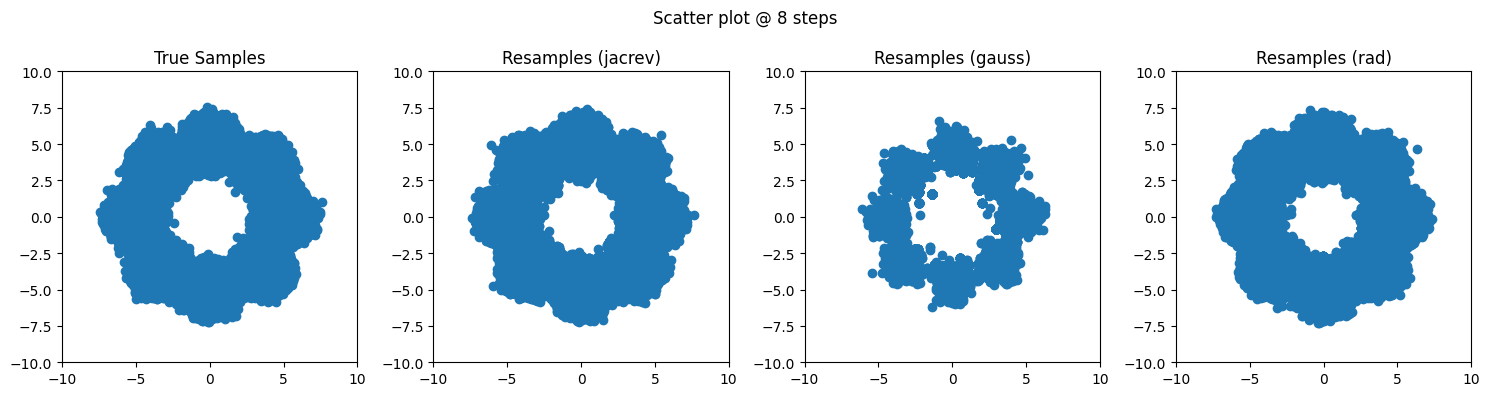

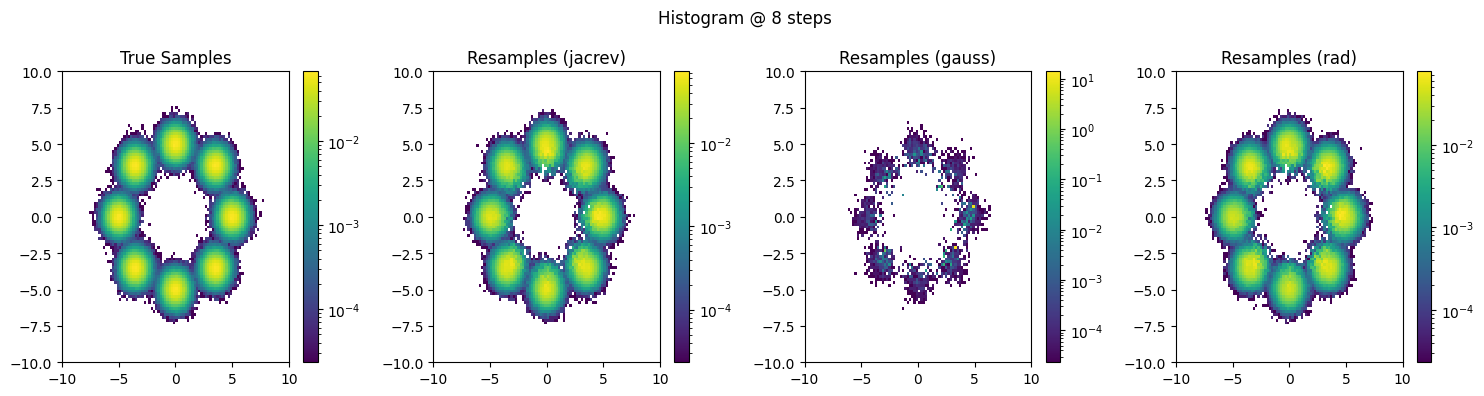

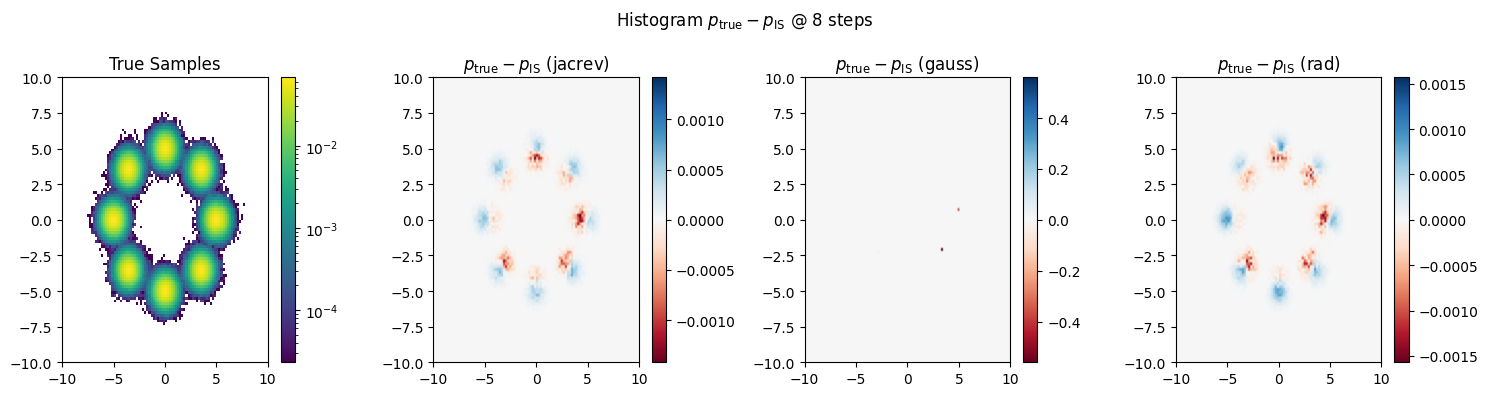

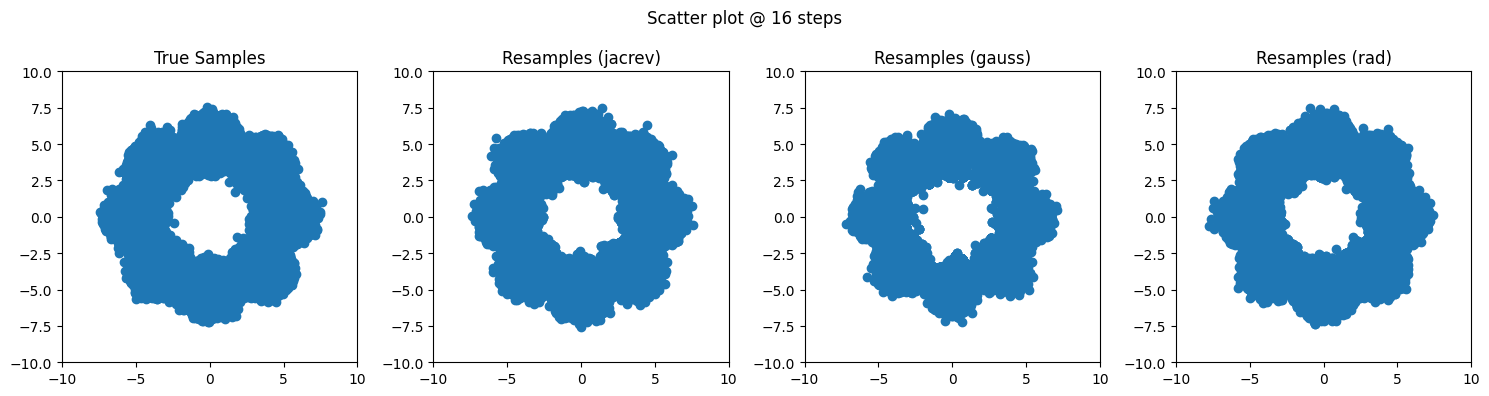

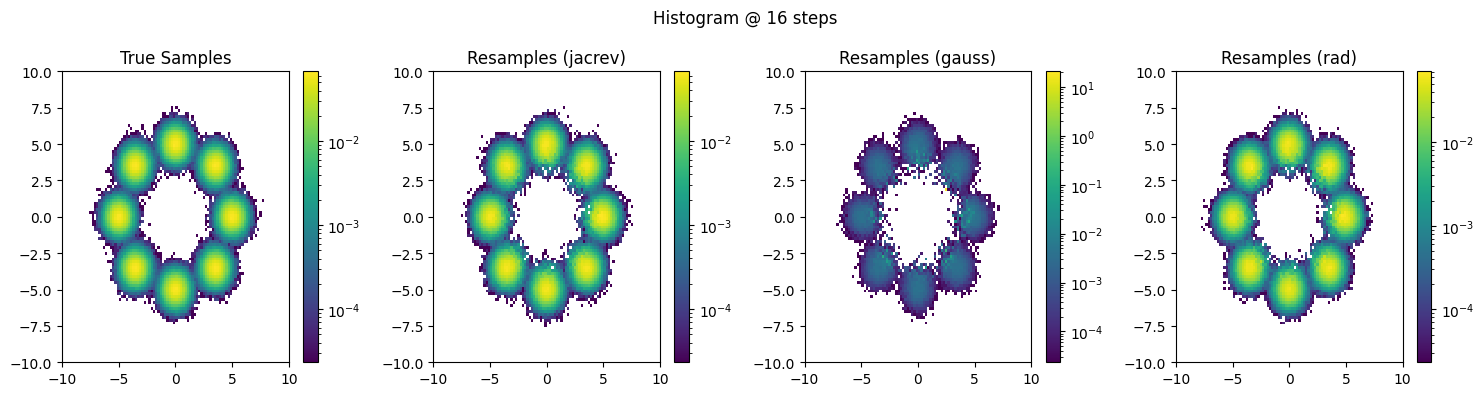

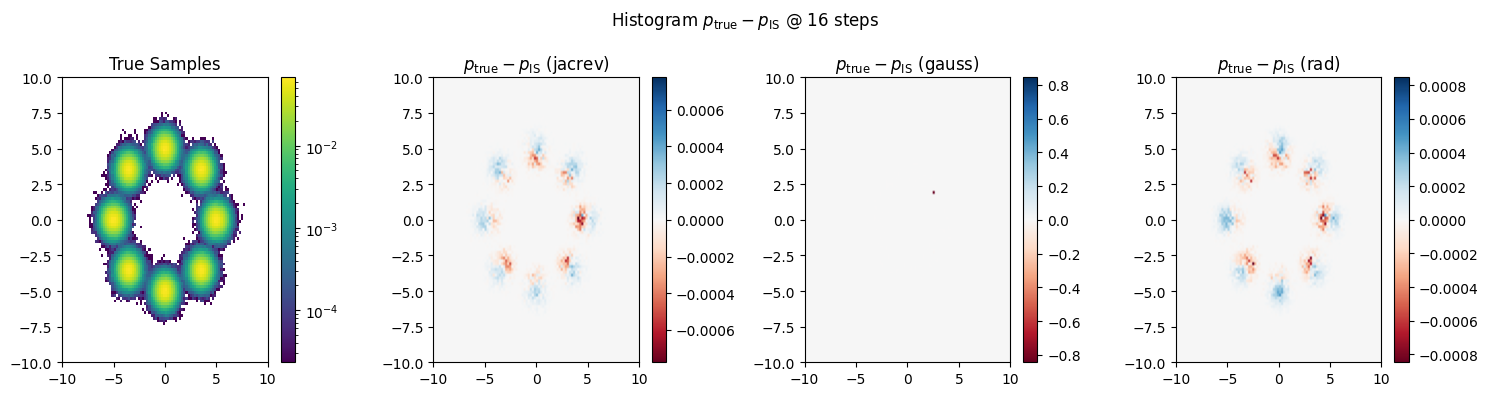

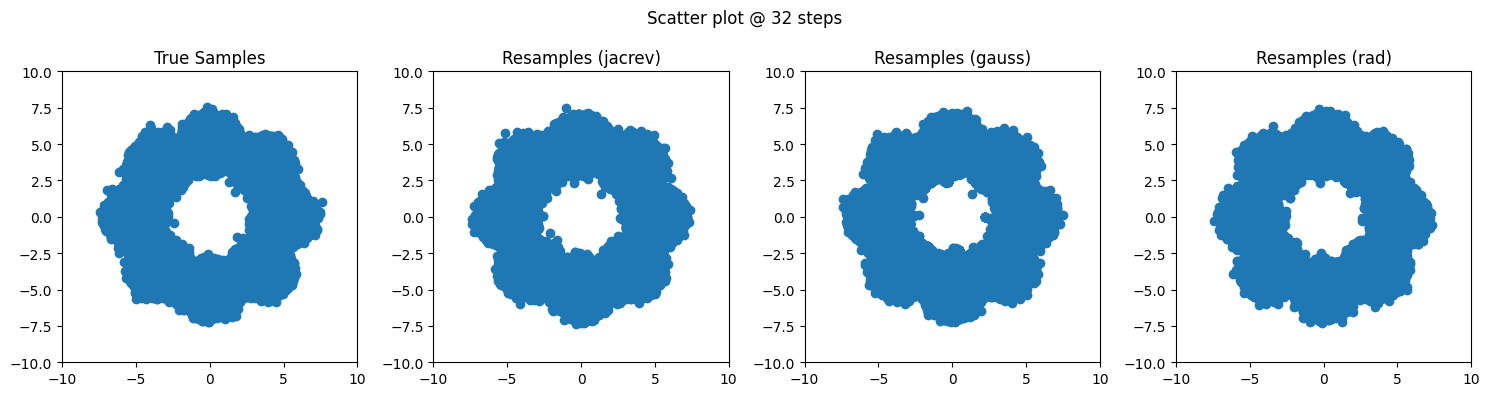

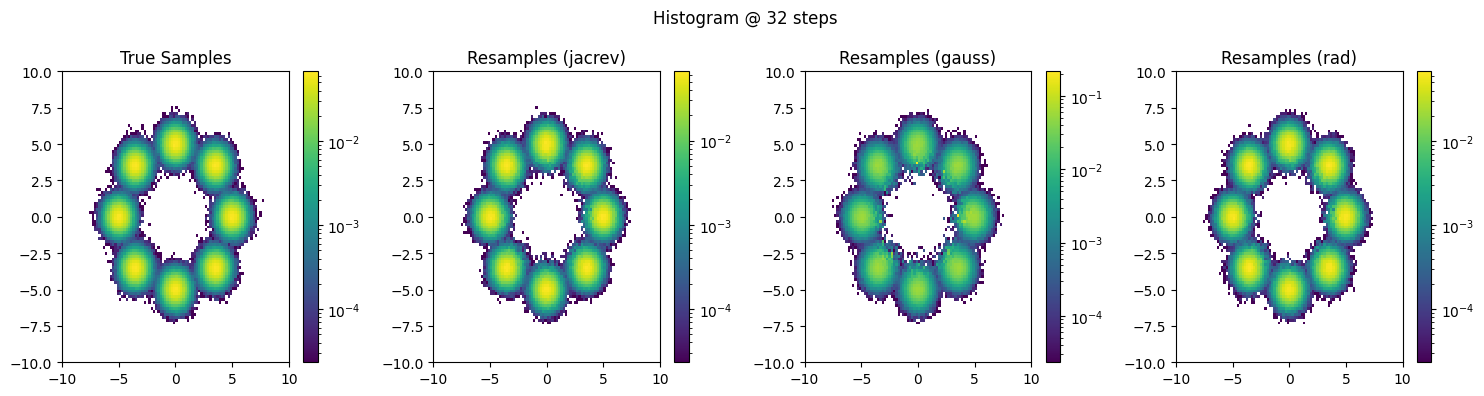

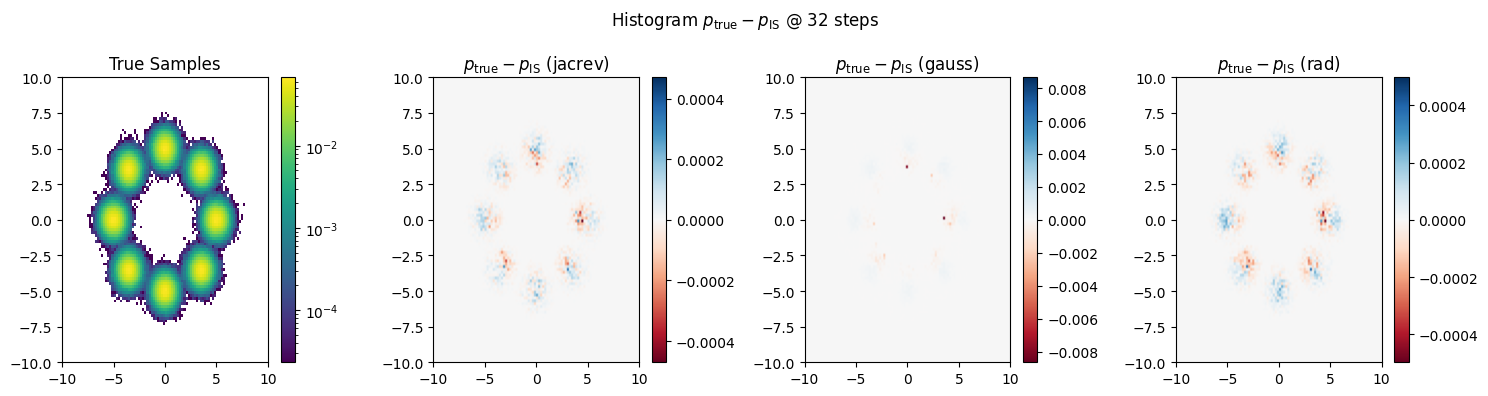

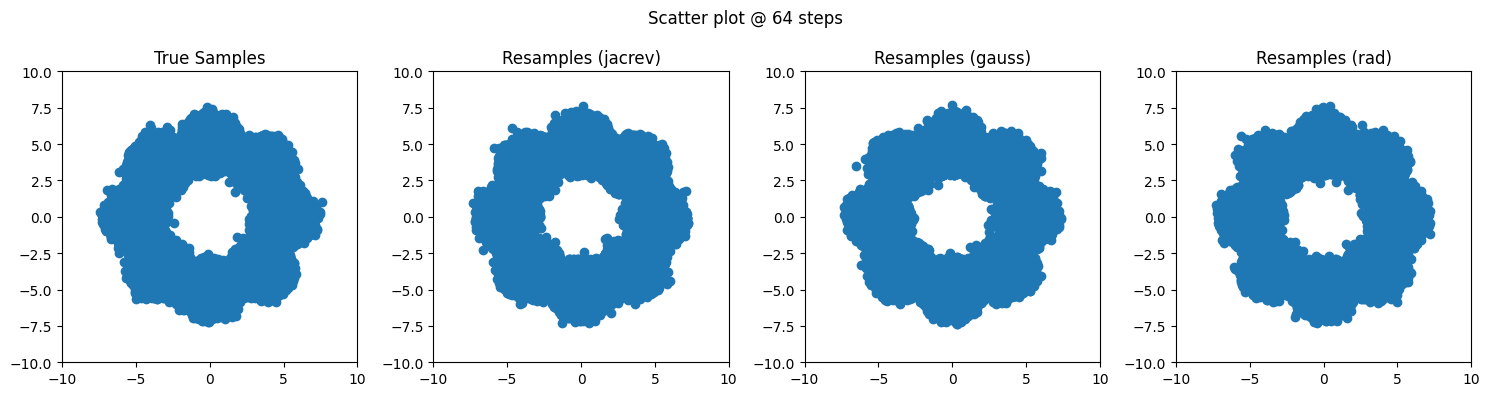

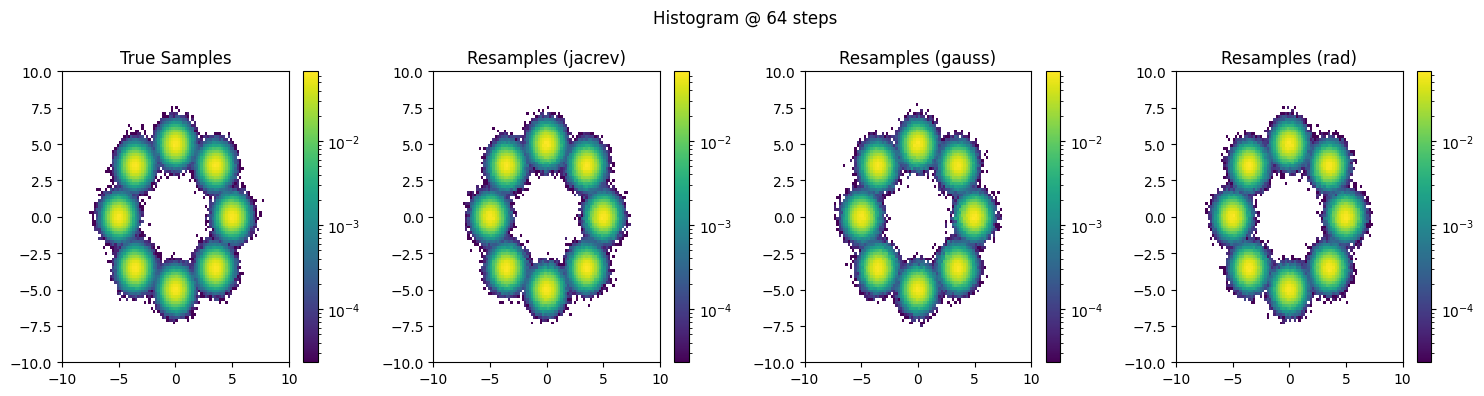

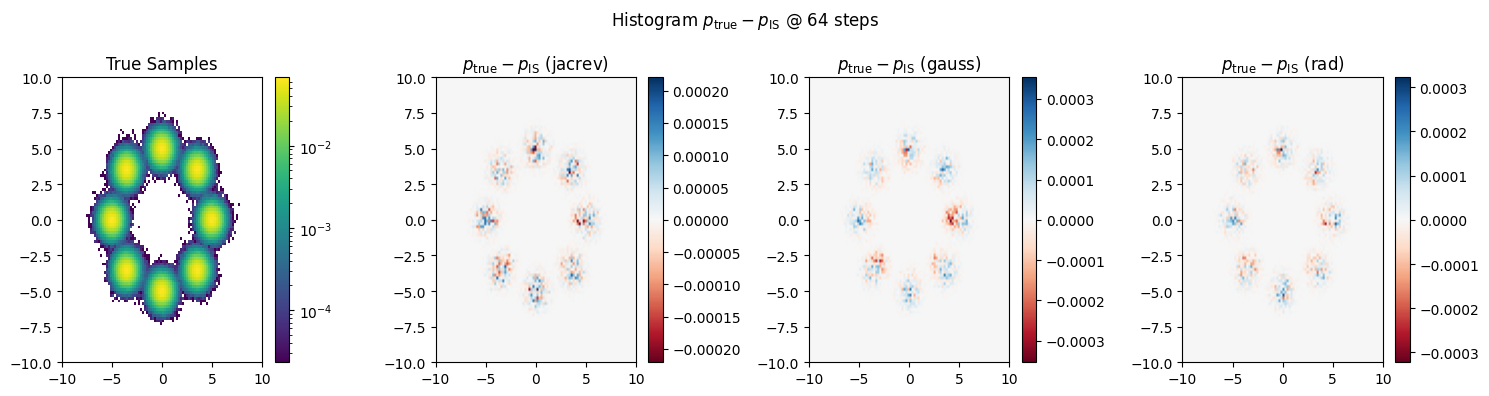

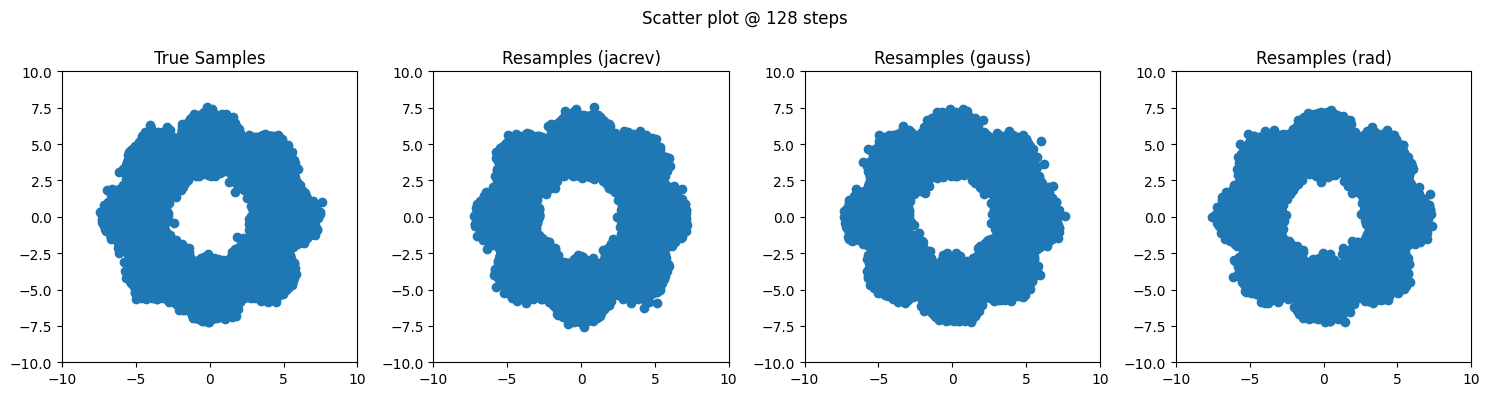

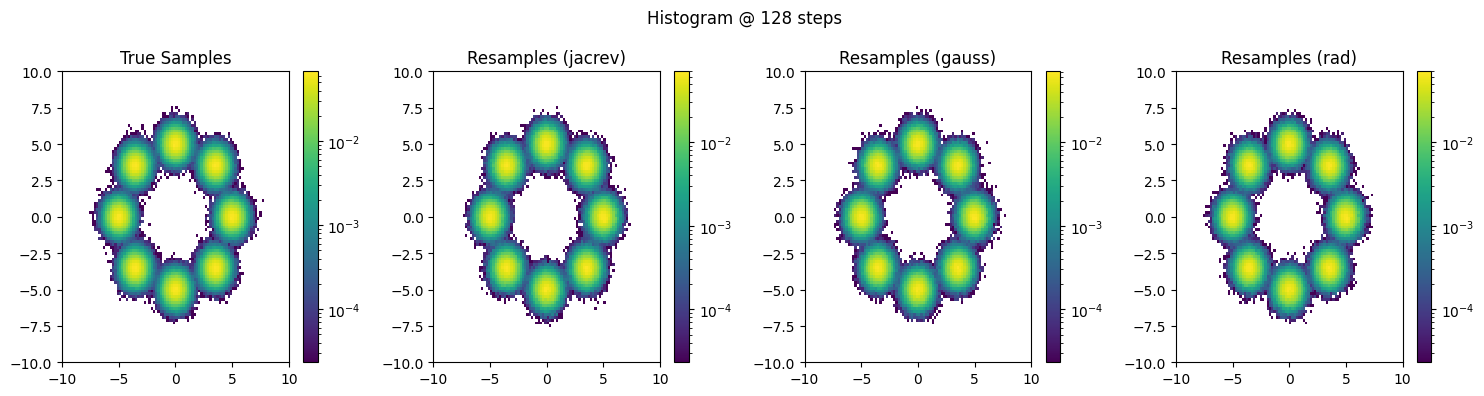

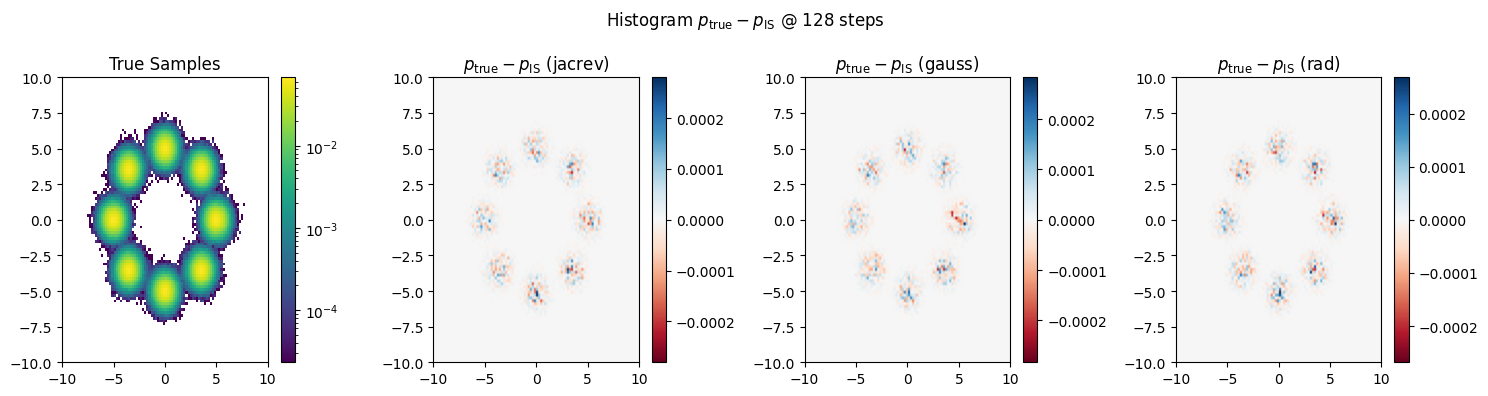

In [13]:
true_samples = eight_normal_sample(num_resamples).numpy()

data_dict = joblib.load(sample_dir + f"/samples_ot_{use_ot}_ema_{use_ema}.pkl")

for num_timestep, data in data_dict.items():

    ## Scatter Plot
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
    fig.suptitle(f"Scatter plot @ {num_timestep} steps")
    scatter_plot(ax1, true_samples, "True Samples")
    for samples, name, ax in zip(data.values(), data.keys(), [ax2, ax3, ax4]):
        if name == "original":
            continue
        scatter_plot(ax, samples, f"Resamples ({name})")

    plt.show()
    fig.savefig(fig_dir + f"/scatter_{num_timestep}_ot_{use_ot}_ema_{use_ema}.png")

    ## Histogram
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
    fig.suptitle(f"Histogram @ {num_timestep} steps")
    histogram_plot(ax1, true_samples, "True Samples")
    for samples, name, ax in zip(data.values(), data.keys(), [ax2, ax3, ax4]):
        if name == "original":
            continue
        histogram_plot(ax, samples, f"Resamples ({name})")

    plt.show()
    fig.savefig(fig_dir + f"/histogram_{num_timestep}_ot_{use_ot}_ema_{use_ema}.png")

    ## Histogram diff plot
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
    fig.suptitle(r"Histogram $p_{\text{true}} -  p_{\text{IS}}$" + f" @ {num_timestep} steps")
    histogram_plot(ax1, true_samples, "True Samples")
    ax1.set_title("True Samples")
    for samples, name, ax in zip(data.values(), data.keys(), [ax2, ax3, ax4]):
        if name == "original":
            continue
        histogram_diff(ax, true_samples, samples, r"$p_{\text{true}} -  p_{\text{IS}}$" + f" ({name})")

    plt.show()
    fig.savefig(fig_dir + f"/histogram_diff_{num_timestep}_ot_{use_ot}_ema_{use_ema}.png")

## Plotting KDE densities

These are a bit slow on 1e9 points so I have separated out

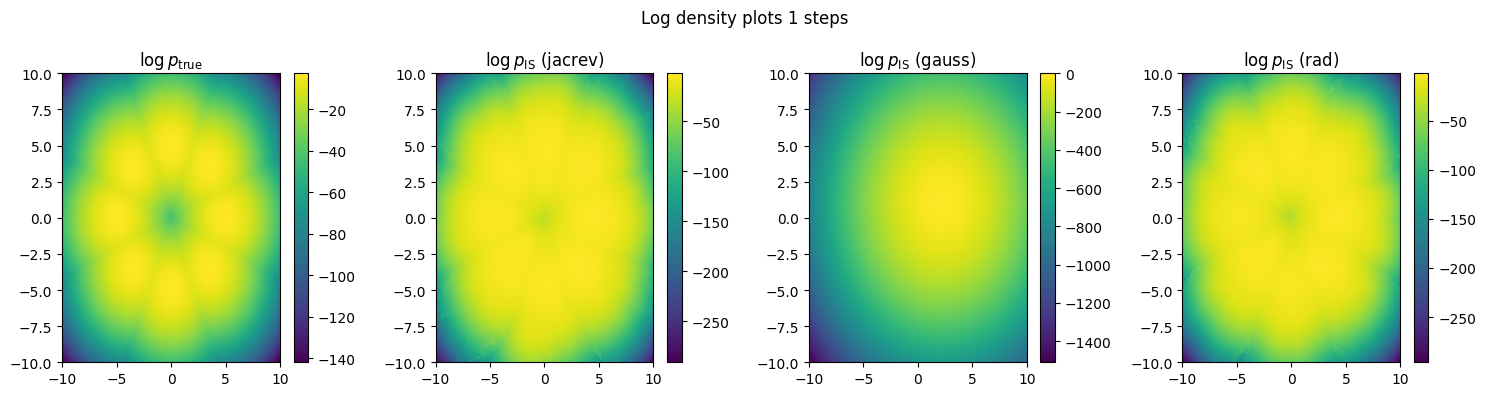

<Figure size 640x480 with 0 Axes>

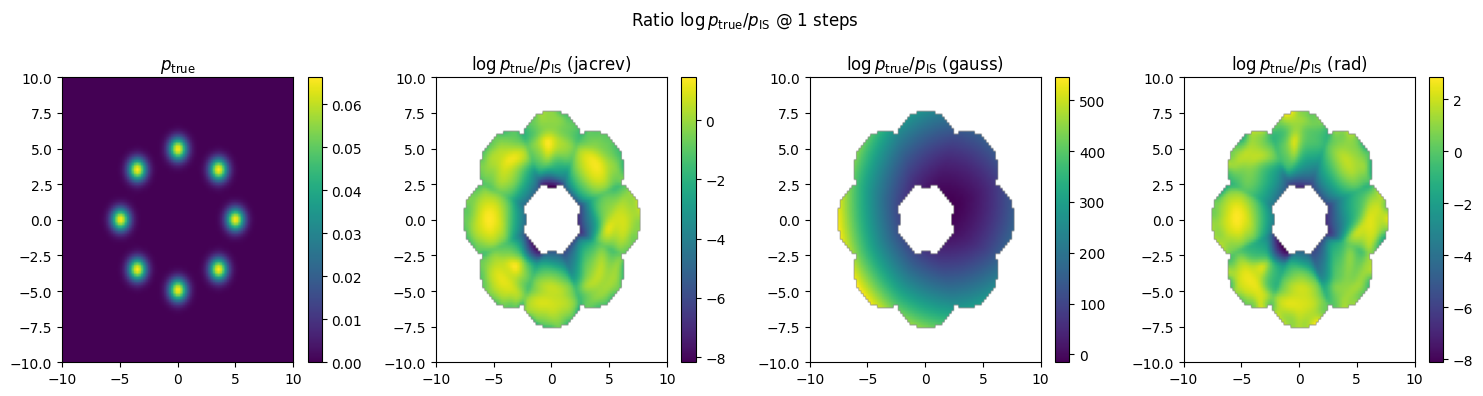

<Figure size 640x480 with 0 Axes>

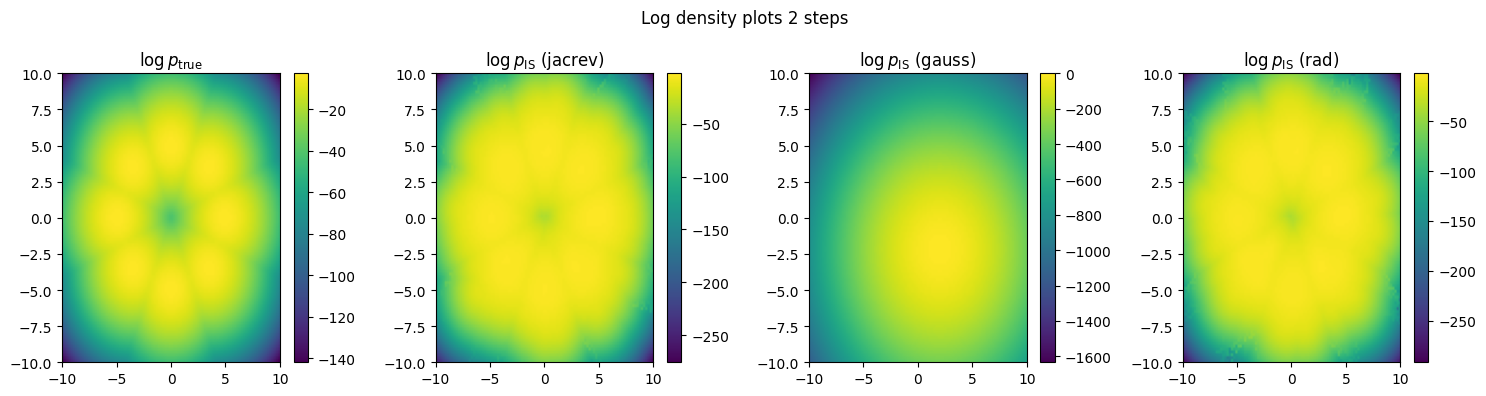

<Figure size 640x480 with 0 Axes>

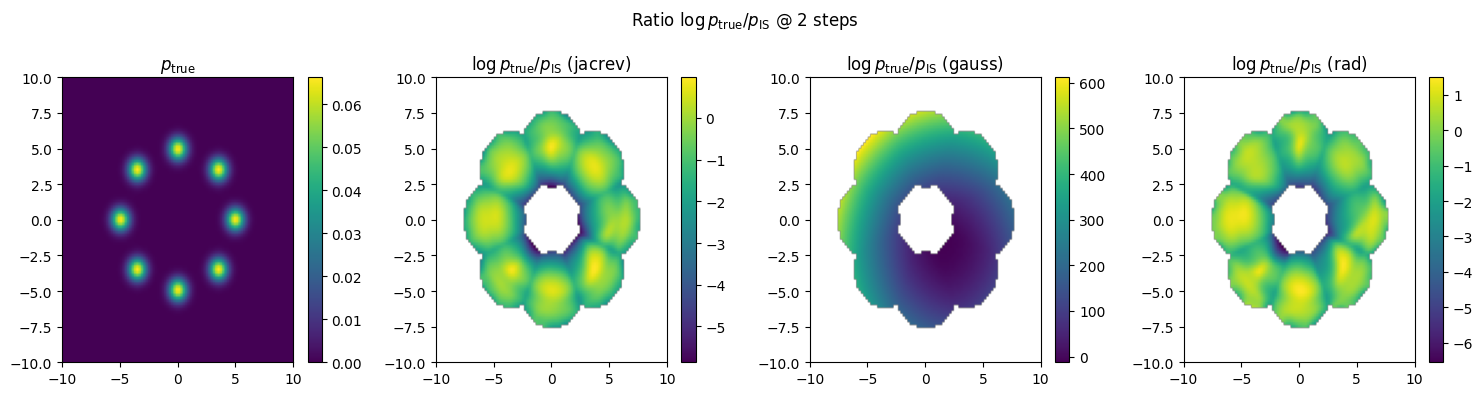

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

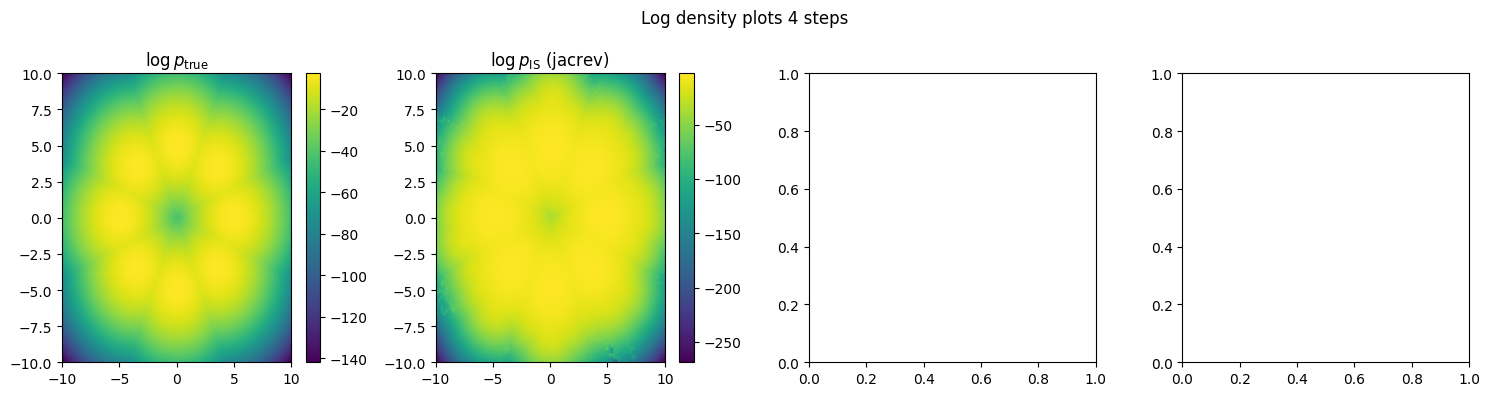

In [13]:
true_log_density_2d = eight_normal_log_prob(torch.tensor(grid)).numpy().reshape(X.shape)

for num_timestep, data in data_dict.items():

    # Density Plot
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
    fig.suptitle(f"Log density plots {num_timestep} steps")
    log_density_dict = {}
    plot_density_2d(ax1, true_log_density_2d, r"$\log p_{\text{true}}$")
    for samples, name, ax in zip(data.values(), data.keys(), [ax2, ax3, ax4]):
        if name == "original":
            continue
        log_density_2d = kde_log_density(samples, grid)
        log_density_dict[name] = log_density_2d
        plot_density_2d(ax, log_density_2d, r"$\log p_{\text{IS}}$" + f" ({name})")

    plt.show()
    plt.savefig(fig_dir + f"/density_{num_timestep}_ot_{use_ot}_ema_{use_ema}.png")

    # Density Diff Plot
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
    fig.suptitle(f"Ratio " + r"$\log p_{\text{true}}/p_{\text{IS}}$" +  f" @ {num_timestep} steps")
    plot_density_2d(ax1, np.exp(true_log_density_2d), r"$p_{\text{true}}$")
    for samples, name, ax in zip(data.values(), data.keys(), [ax2, ax3, ax4]):
        if name == "original":
            continue
        log_density_2d = kde_log_density(samples, grid)
        plot_values = true_log_density_2d - log_density_2d
        plot_values = np.where(true_log_density_2d > -15, plot_values, float('nan'))
        plot_density_2d(ax, plot_values, r"$\log p_{\text{true}}/p_{\text{IS}}$" + f" ({name})")

    plt.show()
    plt.savefig(fig_dir + f"/density_diff_{num_timestep}_ot_{use_ot}_ema_{use_ema}.png")

In [ ]:
## NOT CURRENTLY WORKING


class cnf_wrapper(torch.nn.Module):
    """Wraps model to a torchdyn compatible CNF format.
    Appends an additional dimension representing the change in likelihood
    over time.
    """

    def __init__(self, model, likelihood_estimator="hutch_rademacher"):
        super().__init__()
        self.model = model
        self.div_fn, self.eps_fn = self.get_div_and_eps(likelihood_estimator)

    def get_div_and_eps(self, likelihood_estimator):
        if likelihood_estimator == "exact":
            return exact_div_fn, None
        if likelihood_estimator == "hutch_gaussian":
            return div_fn_hutch_trace, torch.randn_like
        if likelihood_estimator == "hutch_rademacher":

            def eps_fn(x):
                return torch.randint_like(x, low=0, high=2).float() * 2 - 1.0

            return div_fn_hutch_trace, eps_fn
        raise NotImplementedError(
            f"likelihood estimator {likelihood_estimator} is not implemented"
        )

    def forward(self, t, input, *args, **kwargs):

        t = t.squeeze()

        x = input[:, :2]
        div = input[:, 2]

        def vecfield(y):
            return self.model(torch.cat([y, torch.tensor([t]), torch.tensor([0])]))

        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))

        t_vec = torch.ones(x.shape[0]) * t
        d_vec = torch.ones(x.shape[0]) * int(np.log2(M))

        dx = self.model(torch.cat([x, t_vec[:, None], d_vec[:, None]], dim=-1))
        return torch.cat([dx, div[:, None]], dim=-1)


node = NeuralODE(
    cnf_wrapper(ema), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )

node = NeuralODE(
    cnf_wrapper(ema), solver="euler",
    )

prior_samples = prior.sample((num_samples,))

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([prior_samples, torch.zeros(num_samples)[:, None]], dim=-1),
        t_span=torch.linspace(0, 1, 512),
    )

    samples = traj[-1][:, :2]
    div = traj[-1][:, 2]
    model_log_p = (prior.log_prob(prior_samples) - div).flatten()
    true_log_p = eight_normal_log_prob(samples).flatten()

    resampled_samples = importance_sample(samples, true_log_p, model_log_p, num_samples=num_samples * resampling_factor)
    samples_dict[est_name] = resampled_samples

## Scatter Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 4), tight_layout=True)
fig.suptitle(f"Non-Shortcut Model dopri5")

sc1 = ax1.scatter(true_samples[:,0], true_samples[:,1])
ax1.set_title("True Samples")
sc2 = ax2.scatter(samples[:,0], samples[:,1])
ax2.set_title(f"Resampled Samples (rad)")

plt.show()
plt.clf()

# Density Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 4), tight_layout=True)
fig.suptitle(f"Non-Shortcut Model {denoise_timestep_iter} steps")

plot_density_2d(ax1, true_log_density_2d, r"$\log p_{\text{true}}$")
log_density_2d = kde_log_density(samples, grid)
plot_density_2d(ax2, log_density_2d, r"$\log p_{\text{IS}}$" + f"  ({est_name})")

plt.show()
plt.clf()

# Density Diff Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 4), tight_layout=True)
fig.suptitle(f"Shortcut Model {denoise_timestep_iter} steps")

plot_density_2d(ax1, np.exp(true_log_density_2d), r"$p_{\text{true}}$")
plot_values = true_log_density_2d - log_density_2d
plot_values = np.where(true_log_density_2d > -20, plot_values, float('nan'))
plot_density_2d(ax2, plot_values, r"$\log p_{\text{true}}/p_{\text{IS}}$" + f"  ({name})")

plt.show()
plt.clf()